In [ ]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt

# df = pd.read_csv("sample_submission.csv")
# df

# Data audit → feature selection → train/validation split → exploratory analysis →
# feature engineering → baseline model → improved models → final submission


# target varible = class
# features = u, g, r, i , z and its colours too and spectral type and galaxy popoulation

# supervised

In [ ]:
df = pd.read_csv("/content/train.csv") # this is the data where we can train over model
df

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY
...,...,...,...,...,...,...,...,...,...,...,...,...
577342,577342,223.539288,2.503680,20.828729,18.854201,17.703108,17.190536,16.551356,0.511524,M,Red_Sequence,GALAXY
577343,577343,223.895970,40.769343,23.734743,22.359173,20.697865,19.180264,18.947275,0.658589,M,Red_Sequence,GALAXY
577344,577344,52.258927,0.671887,21.944250,21.215856,19.025966,18.772276,18.203397,0.376342,M,Red_Sequence,GALAXY
577345,577345,247.362248,50.659819,21.969881,21.622766,20.987575,20.930924,21.478134,2.868359,G/K,Blue_Cloud,QSO


# clean the data

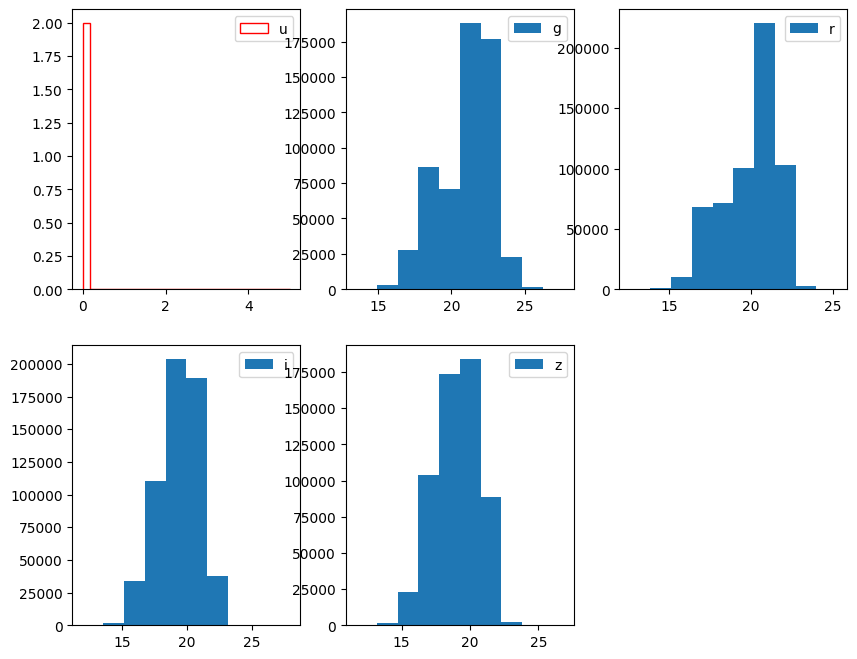

In [ ]:
plt.figure(figsize=[10,8])

plt.subplot(231)
plt.hist(df['u'], bins=np.linspace(0,5,30), ls='--',color='red',histtype='step',facecolor=None, label='u')
plt.legend()

plt.subplot(232)
plt.hist(df['g'], ls='-', label='g')
plt.legend()

plt.subplot(233)
plt.hist(df['r'], ls='-', label='r')
plt.legend()

plt.subplot(234)
plt.hist(df['i'], ls='-', label='i')
plt.legend()

plt.subplot(235)
plt.hist(df['z'], ls='-', label='z')
plt.legend()


In [ ]:
print(len(df))
df = df[df['u']>=5]
df = df[np.isfinite(df['u']) & np.isfinite(df['g']) & np.isfinite(df['r']) & np.isfinite(df['i']) & np.isfinite(df['z'])]
print(len(df))

577347
577344


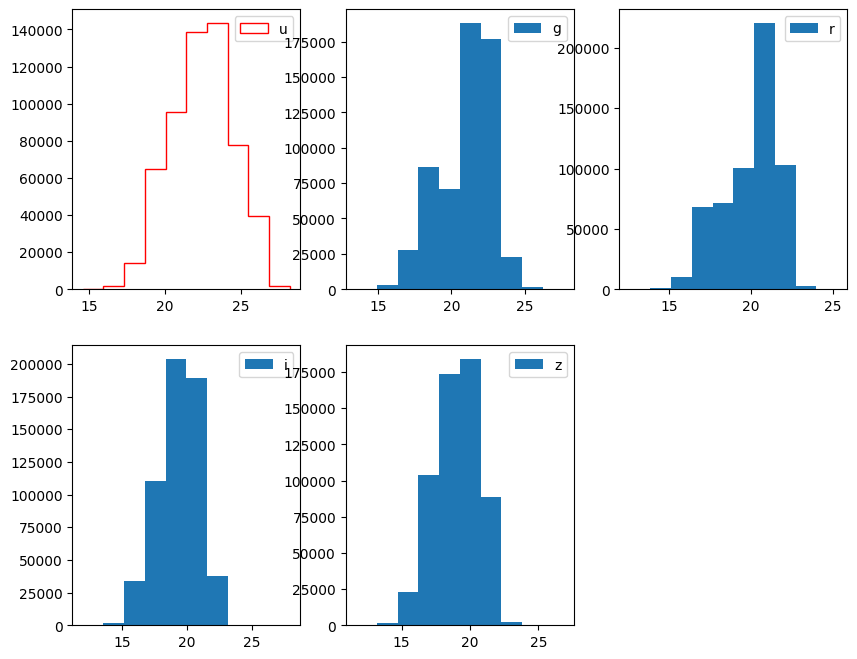

In [ ]:
plt.figure(figsize=[10,8])

plt.subplot(231)
plt.hist(df['u'], ls='--',color='red',histtype='step',facecolor=None, label='u')
plt.legend()

plt.subplot(232)
plt.hist(df['g'], ls='-', label='g')
plt.legend()

plt.subplot(233)
plt.hist(df['r'], ls='-', label='r')
plt.legend()

plt.subplot(234)
plt.hist(df['i'], ls='-', label='i')
plt.legend()

plt.subplot(235)
plt.hist(df['z'], ls='-', label='z')
plt.legend()


In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()
df['spectral_type'] = label_encoder.fit_transform(df['spectral_type'])
df['galaxy_population'] = label_encoder.fit_transform(df['galaxy_population'])
df['class'] = label_encoder.fit_transform(df['class'])

In [ ]:
df['spectral_type']

,spectral_type
0,2
1,2
2,3
3,2
4,2
...,...
577342,2
577343,2
577344,2
577345,1


In [ ]:
df['galaxy_population']

,galaxy_population
0,1
1,1
2,0
3,1
4,1
...,...
577342,1
577343,1
577344,1
577345,0


In [ ]:
# spectral_encoder = LabelEncoder()
# population_encoder = LabelEncoder()

# df['spectral_type'] = spectral_encoder.fit_transform(
#     df['spectral_type']
# )

# df['galaxy_population'] = population_encoder.fit_transform(
#     df['galaxy_population']
# )

In [ ]:
df['u-g'] = df['u'] - df['g']
df['g-r'] = df['g'] - df['r']
df['r-i'] = df['r'] - df['i']
df['i-z'] = df['i'] - df['z']

In [ ]:
# df['u-r'] = df['u'] - df['r']
# df['u-i'] = df['u'] - df['i']
# df['u-z'] = df['u'] - df['z']

# df['g-i'] = df['g'] - df['i']
# df['g-z'] = df['g'] - df['z']

# df['r-z'] = df['r'] - df['z']

In [ ]:
df.columns

Index(['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
       'spectral_type', 'galaxy_population', 'class', 'u-g', 'g-r', 'r-i',
       'i-z'],
      dtype='object')

In [ ]:
target = 'class'
features = [col for col in df.columns if (col != target)]

In [ ]:
features = [col for col in features if (col != 'id') and (col != 'alpha') and (col != 'delta')
            and (col != 'redshift')]

In [ ]:
features

['u',
 'g',
 'r',
 'i',
 'z',
 'spectral_type',
 'galaxy_population',
 'u-g',
 'g-r',
 'r-i',
 'i-z']

In [ ]:
X = df[features].values
y = df[target].values

In [ ]:
y

array([0, 0, 1, ..., 0, 1, 1])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_validate, y_train, y_validate = train_test_split(
    X,
    y,
    test_size=0.3, #  30 percent is validate data
    random_state=42,
    stratify=y
)

X_validate, X_test, y_validate, y_test = train_test_split(
    X_validate,
    y_validate,
    test_size=0.5, #  20 percent is validate data
    random_state=42,
    stratify=y_validate
)

# Decision Tree Regression

In [ ]:
from sklearn.tree import DecisionTreeClassifier
# Initialize the model/ instance
dtree = DecisionTreeClassifier()

# Fit the model parameters using the training dataset
dtree.fit(X_train, y_train)

DecisionTreeClassifier()

MSE = 0.3698


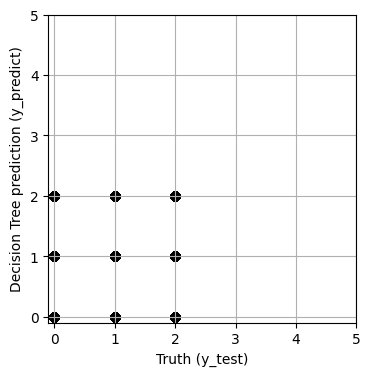

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

y_predict = dtree.predict(X_test)
print(f'MSE = {mean_squared_error(y_test, y_predict):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(y_test, y_predict, alpha=0.2, color='black')
ax.set_aspect('equal')
ax.set_xlim(-0.1, 5)
ax.set_ylim(-0.1, 5)
ax.grid()
ax.set_xlabel('Truth (y_test)') # which is the true result
ax.set_ylabel('Decision Tree prediction (y_predict)')
plt.show()

Accuracy: 0.8408235375626429
Macro F1: 0.756984497339945
              precision    recall  f1-score   support

           0       0.92      0.92      0.92     56623
           1       0.78      0.77      0.78     17571
           2       0.56      0.58      0.57     12408

    accuracy                           0.84     86602
   macro avg       0.76      0.76      0.76     86602
weighted avg       0.84      0.84      0.84     86602



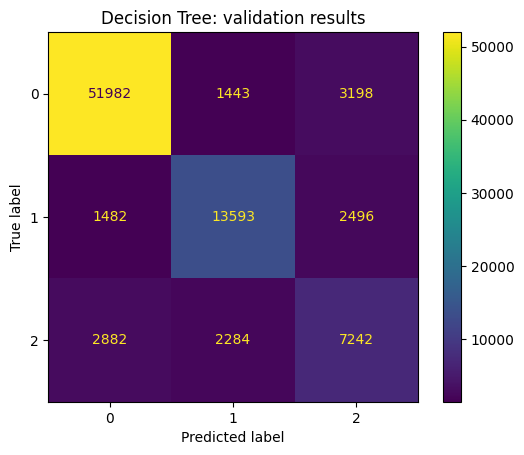

In [ ]:
from sklearn.metrics import (accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay)

print(
    "Accuracy:",
    accuracy_score(y_test, y_predict)
)

print("Macro F1:",f1_score(y_test, y_predict,average="macro"))
print(classification_report(y_test, y_predict))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_predict
)

plt.title("Decision Tree: validation results")
plt.show()

# lets hyperfine the hyperparameter.

In [ ]:
DecisionTreeClassifier().get_params().keys()

dict_keys(['ccp_alpha', 'class_weight', 'criterion', 'max_depth', 'max_features', 'max_leaf_nodes', 'min_impurity_decrease', 'min_samples_leaf', 'min_samples_split', 'min_weight_fraction_leaf', 'monotonic_cst', 'random_state', 'splitter'])

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, validation_curve
hyperparameter_distributions = {
    'max_depth': np.arange(1, 20, 2).astype(int),
    'min_samples_split': np.arange(5, 105, 10).astype(int),
    'min_samples_leaf': np.arange(5, 105, 10).astype(int)
}

random_search = RandomizedSearchCV(
    dtree,
    param_distributions=hyperparameter_distributions,
    n_iter=100
)

random_search.fit(X_validate, y_validate.flatten())

RandomizedSearchCV(estimator=DecisionTreeClassifier(), n_iter=100,
                   param_distributions={'max_depth': array([ 1,  3,  5,  7,  9, 11, 13, 15, 17, 19]),
                                        'min_samples_leaf': array([ 5, 15, 25, 35, 45, 55, 65, 75, 85, 95]),
                                        'min_samples_split': array([ 5, 15, 25, 35, 45, 55, 65, 75, 85, 95])})

In [ ]:
print(random_search.best_params_)

{'min_samples_split': np.int64(55), 'min_samples_leaf': np.int64(15), 'max_depth': np.int64(9)}


# apply on the test again to see if it improved or not

In [ ]:
print(random_search.best_params_)
params = {
    "min_samples_split": 55,
    "min_samples_leaf": 15,
    "max_depth": 9,
}

# Initialize the model
dtree = DecisionTreeClassifier(**params)

dtree.fit(X_train, y_train)

{'min_samples_split': np.int64(55), 'min_samples_leaf': np.int64(15), 'max_depth': np.int64(9)}


DecisionTreeClassifier(max_depth=9, min_samples_leaf=15, min_samples_split=55)

MSE = 0.2496


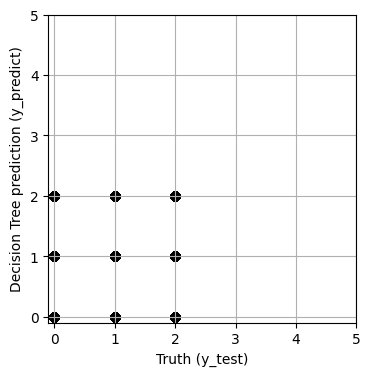

In [ ]:
y_predict = dtree.predict(X_test)
print(f'MSE = {mean_squared_error(y_test, y_predict):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(y_test, y_predict, alpha=0.2, color='black')
ax.set_aspect('equal')
ax.set_xlim(-0.1, 5)
ax.set_ylim(-0.1, 5)
ax.grid()
ax.set_xlabel('Truth (y_test)')
ax.set_ylabel('Decision Tree prediction (y_predict)')
plt.show()

Accuracy: 0.8884205907484816
Macro F1: 0.8171850733273497
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     56623
           1       0.82      0.86      0.84     17571
           2       0.72      0.61      0.66     12408

    accuracy                           0.89     86602
   macro avg       0.83      0.81      0.82     86602
weighted avg       0.88      0.89      0.89     86602



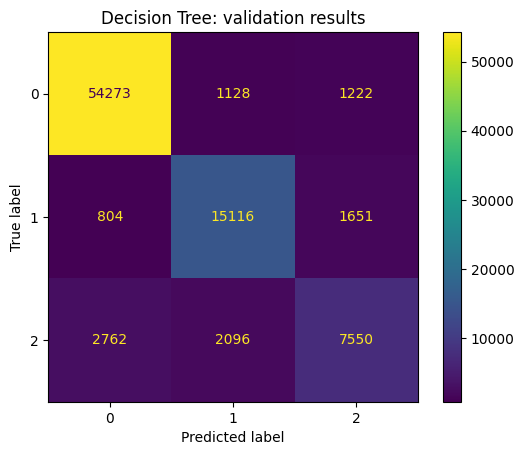

In [ ]:
from sklearn.metrics import (accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay)

print(
    "Accuracy:",
    accuracy_score(y_test, y_predict)
)

print("Macro F1:",f1_score(y_test, y_predict,average="macro"))
print(classification_report(y_test, y_predict))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_predict
)

plt.title("Decision Tree: validation results")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# use the same parameters as the Decision Tree
params = {
    "min_samples_split": 95,
    "min_samples_leaf": 55,
    "max_depth": 13,
}

# Initialize the model
rf = RandomForestRegressor(**params)

rf.fit(X_train, y_train)

In [ ]:
y_predict = rf.predict(X_test)
print(f'MSE = {mean_squared_error(y_test, y_predict):.4f}')

fig, ax = plt.subplots(1, 1, figsize=(4, 4))

ax.scatter(y_test, y_predict, alpha=0.2, color='black')
ax.set_aspect('equal')
ax.set_xlim(-0.1, 5)
ax.set_ylim(-0.1, 5)
ax.grid()
ax.set_xlabel('Truth (y_test)')
ax.set_ylabel('Decision Tree prediction (y_predict)')
plt.show()

In [ ]:
max_depths = np.arange(1, 20, 2).astype(int)

train_mse = []
test_mse = []
for depth in max_depths:

    params = {
        "min_samples_split": 95,
        "min_samples_leaf": 55,
        "max_depth": depth,
    }
    rff = RandomForestRegressor(**params)
    rff.fit(X_train, y_train)

    y_predict_train = rff.predict(X_train)
    y_predict_test = rff.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_predict_train))
    test_mse.append(mean_squared_error(y_test, y_predict_test))


fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(max_depths, train_mse, color='blue', label='Training Set')
ax.plot(max_depths, test_mse, color='orange', label='Test Set')
ax.set_xlabel('max depth')
ax.set_ylabel('MSE')
ax.legend()

plt.show()

In [ ]:
from sklearn.metrics import (accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay)

print(
    "Accuracy:",
    accuracy_score(y_validate, y_validate_predict)
)

print("Macro F1:",f1_score(y_validate,y_validate_predict,average="macro"))
print(classification_report(y_validate,y_validate_predict))

ConfusionMatrixDisplay.from_predictions(
    y_validate,
    y_validate_predict
)

plt.title("Decision Tree: validation results")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_train_predict = dtree.predict(X_train_encoded)

train_accuracy = accuracy_score(
    y_train,
    y_train_predict
)

validate_accuracy = accuracy_score(
    y_validate,
    y_validate_predict
)

train_macro_f1 = f1_score(
    y_train,
    y_train_predict,
    average='macro'
)

validate_macro_f1 = f1_score(
    y_validate,
    y_validate_predict,
    average='macro'
)

print(f"Training accuracy   = {train_accuracy:.4f}")
print(f"Validation accuracy = {validate_accuracy:.4f}")

print(f"Training macro F1   = {train_macro_f1:.4f}")
print(f"Validation macro F1 = {validate_macro_f1:.4f}")

In [ ]:
df_test = pd.read_csv("test.csv") # this is the data where we can train over model
df_test

In [ ]:
df_test = pd.read_csv("test.csv") # # data for final predictions
df_test
df_test['u-g'] = df_test['u'] - df_test['g']
df_test['g-r'] = df_test['g'] - df_test['r']
df_test['r-i'] = df_test['r'] - df_test['i']
df_test['i-z'] = df_test['i'] - df_test['z']
features_test = [col for col in df_test.columns if (col != target)]

label_encoder = LabelEncoder()
df_test['spectral_type'] = label_encoder.fit_transform(df_test['spectral_type'])
df_test['galaxy_population'] = label_encoder.fit_transform(df_test['galaxy_population'])
features_test = [col for col in features_test if (col != 'id') and (col != 'alpha') and (col != 'delta')
            and (col != 'redshift')]

X_test = df_test[features_test].values